###Importing SAMFormer

In [1]:
!git clone https://github.com/ri-lind/time-series-forecasting-transformer.git

fatal: destination path 'time-series-forecasting-transformer' already exists and is not an empty directory.


In [2]:
%cd time-series-forecasting-transformer
!git checkout colabsamformer

/content/time-series-forecasting-transformer
Already on 'colabsamformer'
Your branch is up to date with 'origin/colabsamformer'.


In [3]:
!pip install -r requirements.txt

###Actual Code

####Navigation to project folder

In [4]:
# Cding into the project folder so import are recognized
%cd /content/time-series-forecasting-transformer/samformer_pytorch

/content/time-series-forecasting-transformer/samformer_pytorch


####Imports

In [5]:
!pwd
#!pip install --upgrade typing_extensions
import samformer

/content/time-series-forecasting-transformer/samformer_pytorch


In [6]:
import torch
import numpy as np
import pandas as pd
from samformer import SAMFormer
from sklearn.preprocessing import StandardScaler
import requests
from datetime import datetime, timedelta
from io import StringIO
from sklearn.preprocessing import StandardScaler

####Data Collection and Preparation

##### Common

In [7]:
def construct_sliding_window_data(data, seq_len, pred_len, time_increment=1):
    """
    Construct sliding window samples.

    Args:
      data: A 2-D numpy array of shape (T, n_features)
      seq_len: The length of the historical (input) window.
      pred_len: The number of future time steps to predict.
      time_increment: Step size for the sliding window.

    Returns:
      Tuple (x, y) where:
        - x is of shape (n_samples, n_features, seq_len)
        - y is of shape (n_samples, n_features, pred_len)
    """
    n_samples = data.shape[0] - (seq_len - 1) - pred_len
    indices = np.arange(0, n_samples, time_increment)
    x, y = [], []
    for i in indices:
        # Transpose so that each sample becomes (n_features, seq_len)
        x.append(data[i:(i + seq_len)].T)
        y.append(data[(i + seq_len):(i + seq_len + pred_len)].T)
    return np.array(x), np.array(y)

##### Weather Data

In [8]:
# additional import
from numpy.typing import ArrayLike
import kagglehub

def get_weather_data(city: str) -> ArrayLike:
    path = kagglehub.dataset_download("gucci1337/weather-of-albania-last-three-years")
    years = [2021, 2022, 2023]
    data_frames = []

    for year in years:
        file_path = f"{path}/data_weather/{city}/{city}{year}.csv"
        df = pd.read_csv(file_path)
        df = df.dropna(subset=['tavg'])  # Remove rows where 'tavg' is NaN
        data_frames.append(df['tavg'])

    # Concatenate the 'tavg' columns from each year's DataFrame
    concatenated_data = pd.concat(data_frames, ignore_index=True)

    return concatenated_data.values

def read_weather_dataset(seq_len, pred_len, city):
    """
    Load weather data for a given city, split it into train/test,
    standardize using the training set, and apply a sliding window.

    Args:
      seq_len: Length of historical context.
      pred_len: Forecast horizon length.
      city: City name (string) used to fetch data.

    Returns:
      Tuple: ((x_train, y_train),, (x_test, y_test))
    """
    # Load the time series using your function.
    # Assume get_weather_data(city) returns a 1-D list/array.
    ts = get_weather_data(city)

    # Convert to a 2-D array with one column (if univariate)
    ts = np.array(ts).reshape(-1, 1)
    n = len(ts)

    # splitting data 6-4
    train_end = int(n * 0.6)

    train_series = ts[:train_end]
    # To allow full sliding-window samples, include the last seq_len points from train in val/test splits.
    test_series = ts[train_end - seq_len:]

    # normalize training and testing data
    scaler = StandardScaler()
    scaler.fit(train_series)
    train_series = scaler.transform(train_series)
    test_series = scaler.transform(test_series)

    # Construct sliding window samples
    x_train, y_train = construct_sliding_window_data(train_series, seq_len, pred_len)
    x_test, y_test = construct_sliding_window_data(test_series, seq_len, pred_len)

    # Optionally, flatten the target if SAMFormer expects 2D targets (as in your ETTh1 code)
    flatten = lambda y: y.reshape((y.shape[0], y.shape[1] * y.shape[2]))
    y_train, y_test = flatten(y_train), flatten(y_test)

    return (x_train, y_train), (x_test, y_test)


##### Finance Data

In [9]:

# additional import
def get_finance_data():
    """
    Returns a numpy array containing the column with the actual data
    """
    CSV_FILE_ABSOLUTE_PATH = "/content/AMZN-stock-price.csv"

    df = pd.read_csv(CSV_FILE_ABSOLUTE_PATH)

    df = df.iloc[:, 1]

    return df.values


def read_finance_data(seq_len, pred_len):
    """
    Load weather data for a given city, split it into train/test,
    standardize using the training set, and apply a sliding window.

    Args:
      seq_len: Length of historical context.
      pred_len: Forecast horizon length.
      city: City name (string) used to fetch data.

    Returns:
      Tuple: ((x_train, y_train), (x_test, y_test))
    """
    # Load the time series using your function.
    # Assume get_data() returns a 1-D list/array.
    ts = get_finance_data()

    # Convert to a 2-D array with one column (if univariate)
    ts = np.array(ts).reshape(-1, 1)
    n = len(ts)

    # splitting data 6-4
    train_end = int(n * 0.6)

    train_series = ts[:train_end]
    # To allow full sliding-window samples, include the last seq_len points from train in val/test splits.
    test_series = ts[train_end - seq_len:]

    # Normalize data
    scaler = StandardScaler()
    scaler.fit(train_series)
    train_series = scaler.transform(train_series)
    test_series = scaler.transform(test_series)

    # Construct sliding window samples
    x_train, y_train = construct_sliding_window_data(train_series, seq_len, pred_len)
    x_test, y_test = construct_sliding_window_data(test_series, seq_len, pred_len)

    # Optionally, flatten the target if SAMFormer expects 2D targets (as in your ETTh1 code)
    flatten = lambda y: y.reshape((y.shape[0], y.shape[1] * y.shape[2]))
    y_train, y_test = flatten(y_train), flatten(y_test)

    return (x_train, y_train), (x_test, y_test)

##### Energy

In [10]:
def get_energy_data(year):
    """
    Downloads daily consumption data for a given year, concatenates all days into a single DataFrame,
    and performs basic preprocessing (e.g., dropping NaN values).

    Parameters:
        year (int): The year for which to retrieve data.

    Returns:
        pd.DataFrame: Preprocessed DataFrame containing the data from all days.
    """
    all_data = []
    # Define the start and end dates for the year
    current_date = datetime(year, 1, 1)
    end_date = datetime(year, 12, 31)

    while current_date <= end_date:
        # Format the date as day.month.year (e.g., "1.10.2023" for October 1, 2023)
        # Adjust this format if your URL requires zero-padded day/month values.
        date_str = f"{current_date.day}.{current_date.month}.{current_date.year}"

        # Build the URL by inserting the date string into the appropriate place
        url = f"https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t{date_str}"
        print(f"Fetching data for {date_str} from:\n{url}")
        try:
            response = requests.get(url)
            response.raise_for_status()  # Raise an error for bad status codes

            # Read the CSV data from the response.
            # Here, we assume the CSV file uses ';' as a delimiter.
            daily_df = pd.read_csv(StringIO(response.text), sep=';')
            all_data.append(daily_df)
        except Exception as e:
            print(f"Error fetching data for {date_str}: {e}")

        # Move to the next day
        current_date += timedelta(days=1)

    combined_data = pd.concat(all_data, ignore_index=True)
    string_kws = combined_data.iloc[:, 1].values
    values_float = np.array([float(w.replace(',', '')) for w in string_kws])
    return values_float

def read_library_energy_dataset(seq_len, pred_len, year):
    """
    Load weather data for a given city, split it into train/test,
    standardize using the training set, and apply a sliding window.

    Args:
      seq_len: Length of historical context.
      pred_len: Forecast horizon length.
      city: City name (string) used to fetch data.

    Returns:
      Tuple: ((x_train, y_train),, (x_test, y_test))
    """
    # Load the time series using your function.
    # Assume get_weather_data(city) returns a 1-D list/array.
    ts = get_energy_data(year)

    # Convert to a 2-D array with one column (if univariate)
    ts = np.array(ts).reshape(-1, 1)
    n = len(ts)

    # splitting data 6-4
    train_end = int(n * 0.6)

    train_series = ts[:train_end]
    # To allow full sliding-window samples, include the last seq_len points from train in val/test splits.
    test_series = ts[train_end - seq_len:]

    # DID
    scaler = StandardScaler()
    scaler.fit(train_series)
    train_series = scaler.transform(train_series)
    test_series = scaler.transform(test_series)

    # Construct sliding window samples
    x_train, y_train = construct_sliding_window_data(train_series, seq_len, pred_len)
    x_test, y_test = construct_sliding_window_data(test_series, seq_len, pred_len)

    # Optionally, flatten the target if SAMFormer expects 2D targets (as in your ETTh1 code)
    flatten = lambda y: y.reshape((y.shape[0], y.shape[1] * y.shape[2]))
    y_train, y_test = flatten(y_train), flatten(y_test)

    return (x_train, y_train), (x_test, y_test)

##### Healthcare

In [11]:
def get_healthcare_data():
    """
    Returns a numpy array containing the column with the actual data
    """
    CSV_FILE_ABSOLUTE_PATH = "/content/WHO-COVID-19-global-daily-data.csv"

    df = pd.read_csv(CSV_FILE_ABSOLUTE_PATH)
    df = df.sort_values(['Country', 'Date_reported'])
    df['New_cases'] = df.groupby('Country')['New_cases'].transform(lambda group: group.interpolate(method='linear'))

    df = get_new_cases_by_country(df)

    new_cases = df["Germany"][200: 1200]

    return new_cases

def get_new_cases_by_country(df: pd.DataFrame) -> dict:
    """
    Given a DataFrame with columns:
      'Date_reported', 'Country_code', 'Country', 'WHO_region',
      'New_cases', 'Cumulative_cases', 'New_deaths', 'Cumulative_deaths'
    returns a dictionary where:
      - keys are country names (as strings)
      - values are NumPy arrays of new cases (from the 'New_cases' column)

    The function sorts the data by 'Date_reported' for each country to ensure
    a consistent time-series order.
    """
    result = {}
    # Group the data by the 'Country' column
    for country, group in df.groupby('Country'):
        # Sort the group's rows by the reported date
        group_sorted = group.sort_values('Date_reported')
        # Extract the 'New_cases' column as a NumPy array
        new_cases_array = group_sorted['New_cases'].to_numpy()
        result[country] = new_cases_array
    return result

def read_healthcare_data(seq_len, pred_len):
    """
    Load weather data for a given city, split it into train/test,
    standardize using the training set, and apply a sliding window.

    Args:
      seq_len: Length of historical context.
      pred_len: Forecast horizon length.
      city: City name (string) used to fetch data.

    Returns:
      Tuple: ((x_train, y_train), (x_test, y_test))
    """
    # Load the time series using your function.
    # Assume get_data() returns a 1-D list/array.
    ts = get_healthcare_data()

    # Convert to a 2-D array with one column (if univariate)
    ts = np.array(ts).reshape(-1, 1)
    n = len(ts)

    # splitting data 6-4
    train_end = int(n * 0.6)

    train_series = ts[:train_end]
    # To allow full sliding-window samples, include the last seq_len points from train in val/test splits.
    test_series = ts[train_end - seq_len:]

    # Normalize data
    scaler = StandardScaler()
    scaler.fit(train_series)
    train_series = scaler.transform(train_series)
    test_series = scaler.transform(test_series)

    # Construct sliding window samples
    x_train, y_train = construct_sliding_window_data(train_series, seq_len, pred_len)
    x_test, y_test = construct_sliding_window_data(test_series, seq_len, pred_len)

    # Optionally, flatten the target if SAMFormer expects 2D targets (as in your ETTh1 code)
    flatten = lambda y: y.reshape((y.shape[0], y.shape[1] * y.shape[2]))
    y_train, y_test = flatten(y_train), flatten(y_test)

    return (x_train, y_train), (x_test, y_test)

####Testing Lezhe Data Plot

Fetching data for 1.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t1.1.2024
Fetching data for 2.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t2.1.2024
Fetching data for 3.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t3.1.2024
Fetching data for 4.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t4.1.2024
Fetching data for 5.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t5.1.2024
Fetching data for 6.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t6.1.2024
Fetching data for 7.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t7.1.2024
Fetching data for 8.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t8.1.2024
Fetching data for 9.1.2024 from:
https://www.eview.de/e1/p3Export.php?fr

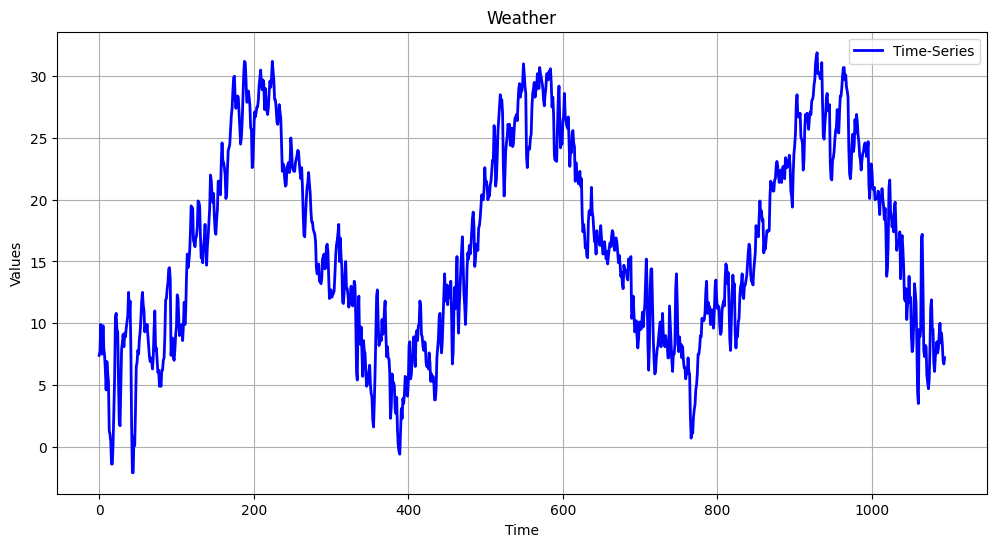

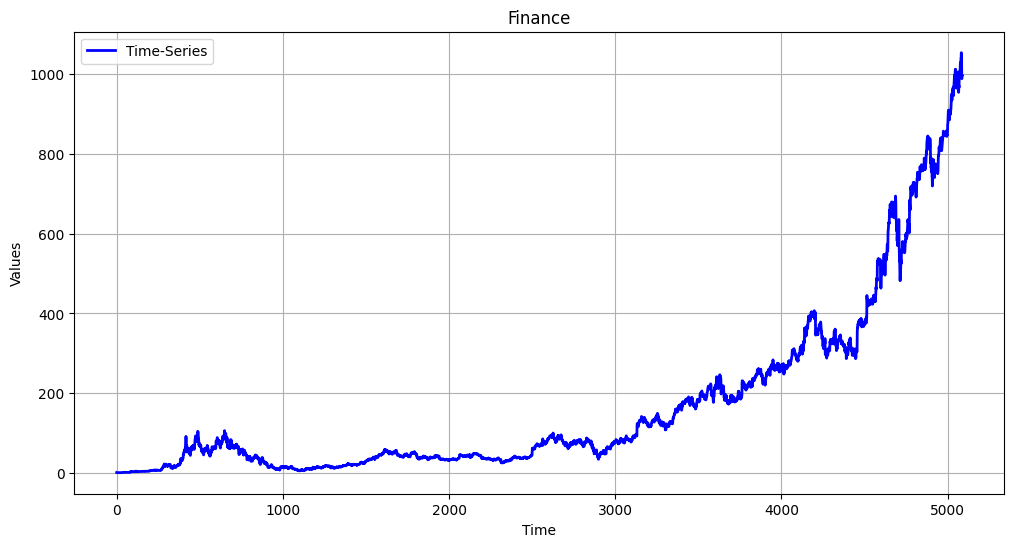

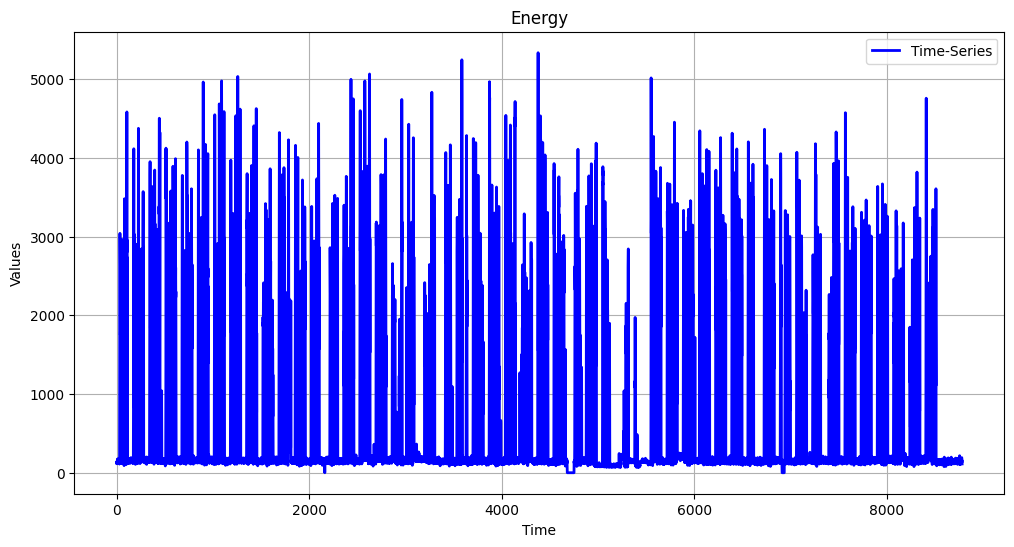

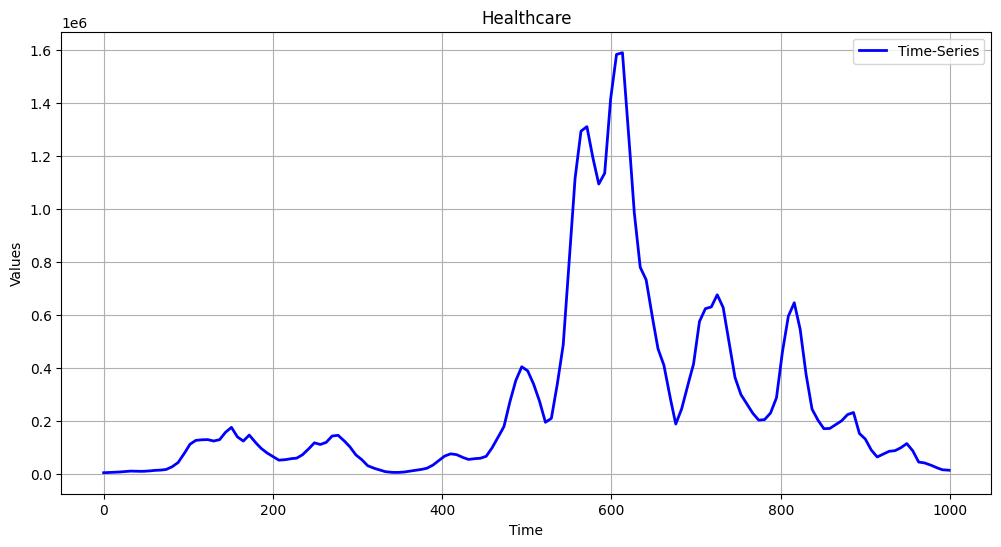

In [13]:
import matplotlib.pyplot as plt
from numpy.typing import ArrayLike

def plot_data(values: ArrayLike, title: str):
    """
    Plot weather data from a 1-D array.

    Args:
      weather_values: A 1-D numpy array containing weather values (e.g., daily average temperatures).
      title: Title for the plot.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(values, label="Time-Series", color="blue", linewidth=2)
    plt.xlabel("Time")
    plt.ylabel("Values")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

weather_data = get_weather_data("lezhe")
finance_data = get_finance_data()
energy_data = get_energy_data(2024)
healthcare_data = get_healthcare_data()
all_data = [(weather_data, "Weather"), (finance_data, "Finance"), (energy_data, "Energy"), (healthcare_data, "Healthcare")]

for data, title in all_data:
  plot_data(data, title)


####Training and Testing

In [14]:
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_from_model_dict(model_dict, sample_index: int = -1, feature_index: int = 0):
    """
    Plots one sample from the test set, showing:
      - Historical (input) data of length seq_len
      - Actual future data of length pred_len
      - Predicted future data of length pred_len

    Args:
        model_dict (dict): Dictionary containing:
            - 'dataset': dataset name
            - 'seq_len': length of historical window
            - 'pred_len': length of forecast horizon
            - 'xy_test': tuple of (x_test, y_test)
            - 'y_pred_test': predicted values
        sample_index (int): Which test sample to plot (default: -1 for the last sample)
        feature_index (int): Which feature to plot (default: 0, if univariate this is the only feature)
    """
    # Extract relevant information
    dataset_name = model_dict.get("dataset", "Unknown_Dataset")
    seq_len = model_dict.get("seq_len", None)
    pred_len = model_dict.get("pred_len", None)
    title = f"{dataset_name}_pred_len_{pred_len}"

    x_test, y_test_flat = model_dict["xy_test"]  # (x_test, y_test)
    y_pred_test_flat = model_dict["y_pred_test"]

    # x_test shape: (n_samples, n_features, seq_len)
    # y_test_flat shape: (n_samples, n_features * pred_len)
    # y_pred_test_flat shape: (n_samples, n_features * pred_len)

    n_samples, n_features, _ = x_test.shape
    # Unflatten y_test and y_pred_test to shape: (n_samples, n_features, pred_len)
    y_test = y_test_flat.reshape(n_samples, n_features, pred_len)
    y_pred_test = y_pred_test_flat.reshape(n_samples, n_features, pred_len)

    # Check sample_index boundaries
    if sample_index >= n_samples or sample_index < -n_samples:
        raise IndexError(f"sample_index {sample_index} is out of range for {n_samples} samples.")

    # Pick the specified sample
    x_hist = x_test[sample_index, feature_index, :]  # shape (seq_len,)
    y_true_future = y_test[sample_index, feature_index, :]  # shape (pred_len,)
    y_pred_future = y_pred_test[sample_index, feature_index, :]  # shape (pred_len,)

    # Construct a time axis for plotting
    # We'll have seq_len points of historical + pred_len points of future
    time_hist = np.arange(seq_len)
    time_future = np.arange(seq_len, seq_len + pred_len)

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(time_hist, x_hist, label="Historical (Input)", color="blue")
    plt.plot(time_future, y_true_future, label="Actual Future", color="green")
    plt.plot(time_future, y_pred_future, label="Predicted Future", color="red", linestyle="--")

    plt.title(title)
    plt.xlabel("Time Index (within this sample)")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)

    # Ensure the save directory exists
    save_dir = "/content/samformer_plots"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"{title}_sample_{sample_index}.png")

    plt.savefig(save_path)
    plt.close()
    print(f"Plot saved to {save_path}")

In [15]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, median_absolute_error, root_mean_squared_error


def mase(y_true, y_pred):
    n = len(y_true)
    m = len(y_true) - 1  # Number of training observations for naive MAE

    # Compute MAE of the model
    mae_model = np.mean(np.abs(y_pred - y_true))

    # Compute MAE of the naïve model (lag-1 forecast)
    naive_mae = np.mean(np.abs(y_true[1:] - y_true[:-1]))

    # Avoid division by zero
    return mae_model / naive_mae if naive_mae != 0 else float("inf")

In [16]:
sequence_lengths = [64, 128, 256]
prediction_lengths = [32, 64, 128]
batch_sizes = [32, 64, 128]

##### Weather Train Test

In [17]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.5.0
    Uninstalling typing_extensions-4.5.0:
      Successfully uninstalled typing_extensions-4.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pymc 5.20.1 requires numpy>=1.25.0, but you have numpy 1.24.3 which is incompatible.
tensorflow 2.18.0 requires flatbuffers>=24.3.25, but you have flatbuffers 23.5.26 which is incompatible.
tensorflow 2.18.0 requires h5py>=3.11.0, but you have h5py 3.10.0 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.3 which is incompatible.
torch 2.5.1+

In [18]:
import optuna
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, r2_score, median_absolute_error
# Assume mase, root_mean_squared_error and read_weather_dataset are defined

# For each weather dataset experiment:
city = "lezhe"
weather_models = []  # to save weather models

print("----- Weather Dataset (City: lezhe) -----")
for i in range(len(sequence_lengths)):
    seq_len = sequence_lengths[i]
    pred_len = prediction_lengths[i]
    batch_size_default = batch_sizes[i]

    # Read weather data for the given city
    (x_train, y_train), (x_test, y_test) = read_weather_dataset(seq_len, pred_len, city)

    # Define the objective function for Optuna tuning
    def objective(trial):
        learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
        weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
        rho = trial.suggest_uniform("rho", 0.3, 0.7)
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

        # Initialize the model with sampled hyperparameters
        model = SAMFormer(num_epochs=10,
                          batch_size=batch_size,
                          base_optimizer=torch.optim.Adam,
                          learning_rate=learning_rate,
                          weight_decay=weight_decay,
                          rho=rho,
                          use_revin=True)
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
        return rmse

    # Run hyperparameter tuning for a set number of trials
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=5)
    best_params = study.best_trial.params
    print(f"Best hyperparameters for experiment {i+1}: {best_params}")

    # Re-instantiate and train the model using the best hyperparameters found
    tuned_model = SAMFormer(num_epochs=100,
                            batch_size=best_params["batch_size"],
                            base_optimizer=torch.optim.Adam,
                            learning_rate=best_params["learning_rate"],
                            weight_decay=best_params["weight_decay"],
                            rho=best_params["rho"],
                            use_revin=True)
    tuned_model.fit(x_train, y_train)

    # Evaluate the tuned model on the test set
    print(f"\nWeather Model {i+1} with seq_len {seq_len}, pred_len {pred_len}, tuned batch_size {best_params['batch_size']}")
    y_pred_test = tuned_model.predict(x_test)

    # Calculate evaluation metrics
    rmse_manual = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
    mase_score = mase(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    mape = mean_absolute_percentage_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    median_ae = median_absolute_error(y_test, y_pred_test)
    rmse_sklearn = root_mean_squared_error(y_test, y_pred_test)

    print("RMSE (manual): ", rmse_manual)
    print("MASE: ", mase_score)
    print("MAE: ", mae)
    print("MAPE: ", mape)
    print("R2 Score: ", r2)
    print("Median Absolute Error: ", median_ae)
    print("RMSE (sklearn): ", rmse_sklearn)

    model_dictionary = {
        "number": i + 1,
        "dataset": "weather",
        "model": tuned_model,
        "seq_len": seq_len,
        "pred_len": pred_len,
        "batch_size": best_params["batch_size"],
        "xy_train": (x_train, y_train),
        "xy_test": (x_test, y_test),
        "y_pred_test": y_pred_test,
        "evaluation_metrics": {
            "RMSE_manual": rmse_manual,
            "MASE": mase_score,
            "MAE": mae,
            "MAPE": mape,
            "R2": r2,
            "Median_AE": median_ae,
            "RMSE_sklearn": rmse_sklearn,
        }
    }
    weather_models.append(model_dictionary)
    plot_from_model_dict(model_dictionary)


----- Weather Dataset (City: lezhe) -----


[I 2025-03-04 17:24:43,405] A new study created in memory with name: no-name-9733c784-7eca-4459-9baf-52f7bd9c5375
<ipython-input-18-94720a841dc8>:22: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
<ipython-input-18-94720a841dc8>:23: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
<ipython-input-18-94720a841dc8>:24: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  rho = trial.suggest_uniform("rho", 0.

Best hyperparameters for experiment 1: {'learning_rate': 0.009106002775850002, 'weight_decay': 0.00014380743268187788, 'rho': 0.6521570121609542, 'batch_size': 128}


Epoch 99: Train Loss 0.3979: 100%|██████████| 100/100 [00:26<00:00,  3.71it/s]



Weather Model 1 with seq_len 64, pred_len 32, tuned batch_size 128
RMSE (manual):  0.4297381183399095
MASE:  2.6186676127218753
MAE:  0.34208796609724
MAPE:  1.2476640552946945
R2 Score:  0.7630703918524521
Median Absolute Error:  0.3001664185465316
RMSE (sklearn):  0.4208512331252733
Plot saved to /content/samformer_plots/weather_pred_len_32_sample_-1.png


...


Weather Model 2 with seq_len 128, pred_len 64, tuned batch_size 32
RMSE (manual):  0.4710177820342209
MASE:  2.9028994776271078
MAE:  0.36890166915073747
MAPE:  1.1176891653976684
R2 Score:  0.7221187109150993
Median Absolute Error:  0.3073283799323512
RMSE (sklearn):  0.46192460078808806
Plot saved to /content/samformer_plots/weather_pred_len_64_sample_-1.png


[I 2025-03-04 17:42:36,420] A new study created in memory with name: no-name-8a3589cb-ccbc-4afa-a82c-f6ada1df5be4
<ipython-input-18-94720a841dc8>:22: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
<ipython-input-18-94720a841dc8>:23: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
<ipython-input-18-94720a841dc8>:24: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  rho = trial.suggest_uniform("rho", 0.

Best hyperparameters for experiment 3: {'learning_rate': 0.0002441516927426728, 'weight_decay': 1.14137578320237e-05, 'rho': 0.40792615390736414, 'batch_size': 64}


Epoch 99: Train Loss 0.3165: 100%|██████████| 100/100 [00:41<00:00,  2.41it/s]



Weather Model 3 with seq_len 256, pred_len 128, tuned batch_size 64
RMSE (manual):  0.41032052790685053
MASE:  2.756199293579401
MAE:  0.33367203310374444
MAPE:  1.1942361339644634
R2 Score:  0.7890650248405242
Median Absolute Error:  0.29382581690365533
RMSE (sklearn):  0.40951695643533326
Plot saved to /content/samformer_plots/weather_pred_len_128_sample_-1.png


##### Energy Train Test

In [26]:
import optuna
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error
# Assume mase() and root_mean_squared_error() are defined elsewhere
# Also assume read_library_energy_dataset is defined

year = 2024
energy_models = []  # to save energy models

# Read the energy dataset once (assuming seq_len and pred_len are defined for the loop)

print("\n----- Energy Dataset (Year: 2024) -----")
for i in range(len(sequence_lengths)):

    seq_len = sequence_lengths[i]
    pred_len = prediction_lengths[i]
    batch_size_default = batch_sizes[i]

    (x_train, y_train), (x_test, y_test) = read_library_energy_dataset(seq_len, pred_len, year)

    # Define an objective function for hyperparameter tuning
    def objective(trial):
        learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
        weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
        rho = trial.suggest_uniform("rho", 0.3, 0.7)
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

        # Create and train the model with the sampled hyperparameters
        model = SAMFormer(num_epochs=10,
                          batch_size=batch_size,
                          base_optimizer=torch.optim.Adam,
                          learning_rate=learning_rate,
                          weight_decay=weight_decay,
                          rho=rho,
                          use_revin=True)
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        # Use RMSE as the objective metric
        rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
        return rmse

    # Run hyperparameter tuning
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=5)
    best_params = study.best_trial.params
    print(f"\nBest hyperparameters for energy model {i+1}: {best_params}")

    # Re-instantiate and train the model with best hyperparameters
    tuned_model = SAMFormer(num_epochs=100,
                            batch_size=best_params["batch_size"],
                            base_optimizer=torch.optim.Adam,
                            learning_rate=best_params["learning_rate"],
                            weight_decay=best_params["weight_decay"],
                            rho=best_params["rho"],
                            use_revin=True)
    tuned_model.fit(x_train, y_train)

    # Evaluate the tuned model on the test set
    print(f"\nEnergy Model {i+1} with seq_len {seq_len}, pred_len {pred_len}, tuned batch_size {best_params['batch_size']}")
    y_pred_test = tuned_model.predict(x_test)

    # Calculate evaluation metrics
    rmse_manual = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
    mase_score = mase(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    mape = mean_absolute_percentage_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)
    median_ae = median_absolute_error(y_test, y_pred_test)
    rmse_sklearn = root_mean_squared_error(y_test, y_pred_test)

    print("RMSE (manual): ", rmse_manual)
    print("MASE: ", mase_score)
    print("MAE: ", mae)
    print("MAPE: ", mape)
    print("R2 Score: ", r2)
    print("Median Absolute Error: ", median_ae)
    print("RMSE (sklearn): ", rmse_sklearn)

    # Save model and metrics in a dictionary
    model_dictionary = {
        "number": i + 1,
        "dataset": "energy",
        "model": tuned_model,
        "seq_len": seq_len,
        "pred_len": pred_len,
        "batch_size": best_params["batch_size"],
        "xy_train": (x_train, y_train),
        "xy_test": (x_test, y_test),
        "y_pred_test": y_pred_test,
        "evaluation_metrics": {
            "RMSE_manual": rmse_manual,
            "MASE": mase_score,
            "MAE": mae,
            "MAPE": mape,
            "R2": r2,
            "Median_AE": median_ae,
            "RMSE_sklearn": rmse_sklearn,
        }
    }
    energy_models.append(model_dictionary)
    plot_from_model_dict(model_dictionary)





----- Energy Dataset (Year: 2024) -----
Fetching data for 1.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t1.1.2024
Fetching data for 2.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t2.1.2024
Fetching data for 3.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t3.1.2024
Fetching data for 4.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t4.1.2024
Fetching data for 5.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t5.1.2024
Fetching data for 6.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t6.1.2024
Fetching data for 7.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t7.1.2024
Fetching data for 8.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t8.1.2024
Fetching data for 9.1.2024 from

[I 2025-03-04 18:50:55,334] A new study created in memory with name: no-name-bb5058e9-42f2-4a67-a646-67c00cb22217
<ipython-input-26-e35bb9920ac2>:24: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
<ipython-input-26-e35bb9920ac2>:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
<ipython-input-26-e35bb9920ac2>:26: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  rho = trial.suggest_uniform("rho", 0.


Best hyperparameters for energy model 1: {'learning_rate': 0.002255614898143474, 'weight_decay': 2.9570545801958755e-06, 'rho': 0.3923887372237793, 'batch_size': 32}


Epoch 99: Train Loss 0.8427: 100%|██████████| 100/100 [03:02<00:00,  1.82s/it]



Energy Model 1 with seq_len 64, pred_len 32, tuned batch_size 32
RMSE (manual):  0.712058357811838
MASE:  1.7937213619535233
MAE:  0.4212557786621469
MAPE:  0.7582726295224078
R2 Score:  0.3770554382854836
Median Absolute Error:  0.16961373970441568
RMSE (sklearn):  0.7066720462312207
Plot saved to /content/samformer_plots/energy_pred_len_32_sample_-1.png
Fetching data for 1.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t1.1.2024
Fetching data for 2.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t2.1.2024
Fetching data for 3.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t3.1.2024
Fetching data for 4.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t4.1.2024
Fetching data for 5.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t5.1.2024
Fetching data for 6.1.2024 from:
https://www.eview.de/e1/p3Ex

...


Energy Model 2 with seq_len 128, pred_len 64, tuned batch_size 32
RMSE (manual):  0.6203977569142016
MASE:  1.5568433243845419
MAE:  0.36745007697725907
MAPE:  0.6953165121074756
R2 Score:  0.529455760153954
Median Absolute Error:  0.14795297754032327
RMSE (sklearn):  0.616908947410437
Plot saved to /content/samformer_plots/energy_pred_len_64_sample_-1.png
Fetching data for 1.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t1.1.2024
Fetching data for 2.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t2.1.2024
Fetching data for 3.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t3.1.2024
Fetching data for 4.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t4.1.2024
Fetching data for 5.1.2024 from:
https://www.eview.de/e1/p3Export.php?frame=StadtMS&p=0005;S~00000936;dg1;t5.1.2024
Fetching data for 6.1.2024 from:
https://www.eview.de/e1/p3E

[I 2025-03-04 19:06:36,752] A new study created in memory with name: no-name-80f6bcca-c78e-4741-9e98-761c56b20bac
<ipython-input-26-e35bb9920ac2>:24: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
<ipython-input-26-e35bb9920ac2>:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
<ipython-input-26-e35bb9920ac2>:26: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  rho = trial.suggest_uniform("rho", 0.


Best hyperparameters for energy model 3: {'learning_rate': 0.0008912267322323844, 'weight_decay': 1.1507362250588733e-06, 'rho': 0.32020307328293535, 'batch_size': 64}


Epoch 99: Train Loss 0.4275: 100%|██████████| 100/100 [01:56<00:00,  1.17s/it]



Energy Model 3 with seq_len 256, pred_len 128, tuned batch_size 64
RMSE (manual):  0.5424834515033238
MASE:  1.2659758276454383
MAE:  0.30308190291040144
MAPE:  0.6556286392524258
R2 Score:  0.6441593303907712
Median Absolute Error:  0.12467930660749393
RMSE (sklearn):  0.5419392228066624
Plot saved to /content/samformer_plots/energy_pred_len_128_sample_-1.png


##### Finance Train Test

In [27]:
import optuna
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error
# Assume mase() and root_mean_squared_error() are defined elsewhere
# Also assume read_finance_data is defined

finance_models = []  # to store finance models

print("\n----- Finance Dataset -----")
for i in range(len(sequence_lengths)):
    seq_len = sequence_lengths[i]
    pred_len = prediction_lengths[i]
    batch_size_default = batch_sizes[i]

    # Read finance data for current experiment
    (x_train, y_train), (x_test, y_test) = read_finance_data(seq_len, pred_len)

    # Define an objective function for hyperparameter tuning
    def objective(trial):
        learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
        weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
        rho = trial.suggest_uniform("rho", 0.3, 0.7)
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

        # Instantiate SAMFormer with the sampled hyperparameters
        model = SAMFormer(num_epochs=10,
                          batch_size=batch_size,
                          base_optimizer=torch.optim.Adam,
                          learning_rate=learning_rate,
                          weight_decay=weight_decay,
                          rho=rho,
                          use_revin=True)
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        # Use RMSE as the objective metric for minimization
        rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
        return rmse

    # Run hyperparameter optimization
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=5)
    best_params = study.best_trial.params
    print(f"\nBest hyperparameters for finance model {i+1}: {best_params}")

    # Re-instantiate and train the model with the best hyperparameters
    tuned_model = SAMFormer(num_epochs=100,
                            batch_size=best_params["batch_size"],
                            base_optimizer=torch.optim.Adam,
                            learning_rate=best_params["learning_rate"],
                            weight_decay=best_params["weight_decay"],
                            rho=best_params["rho"],
                            use_revin=True)
    tuned_model.fit(x_train, y_train)

    # Evaluate the tuned model on the test set
    print(f"\nFinance Model {i+1} with seq_len {seq_len}, pred_len {pred_len}, tuned batch_size {best_params['batch_size']}")
    y_pred_test = tuned_model.predict(x_test)

    # Manual RMSE and MASE calculations
    rmse_manual = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
    print("RMSE (manual): ", rmse_manual)
    mase_score = mase(y_test, y_pred_test)
    print("MASE: ", mase_score)

    # Additional sklearn metrics
    mae = mean_absolute_error(y_test, y_pred_test)
    print("MAE: ", mae)
    mape = mean_absolute_percentage_error(y_test, y_pred_test)
    print("MAPE: ", mape)
    r2 = r2_score(y_test, y_pred_test)
    print("R2 Score: ", r2)
    median_ae = median_absolute_error(y_test, y_pred_test)
    print("Median Absolute Error: ", median_ae)
    rmse_sklearn = root_mean_squared_error(y_test, y_pred_test)
    print("RMSE (sklearn): ", rmse_sklearn)

    model_dictionary = {
        "number": i + 1,
        "dataset": "finance",
        "model": tuned_model,
        "seq_len": seq_len,
        "pred_len": pred_len,
        "batch_size": best_params["batch_size"],
        "xy_train": (x_train, y_train),
        "xy_test": (x_test, y_test),
        "y_pred_test": y_pred_test,
        "evaluation_metrics": {
            "RMSE_manual": rmse_manual,
            "MASE": mase_score,
            "MAE": mae,
            "MAPE": mape,
            "R2": r2,
            "Median_AE": median_ae,
            "RMSE_sklearn": rmse_sklearn,
        }
    }
    finance_models.append(model_dictionary)
    plot_from_model_dict(model_dictionary)



[I 2025-03-04 19:09:38,183] A new study created in memory with name: no-name-f80b7ea6-415e-4829-8645-5e66ad155c62
<ipython-input-27-9cb10d2ab29a>:21: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
<ipython-input-27-9cb10d2ab29a>:22: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
<ipython-input-27-9cb10d2ab29a>:23: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  rho = trial.suggest_uniform("rho", 0.


----- Finance Dataset -----


Epoch 9: Train Loss 0.1252: 100%|██████████| 10/10 [00:12<00:00,  1.28s/it]
[I 2025-03-04 19:09:51,002] Trial 0 finished with value: 1.2371084606163036 and parameters: {'learning_rate': 0.0058431600675241165, 'weight_decay': 3.0104503010959232e-05, 'rho': 0.30259035087764535, 'batch_size': 32}. Best is trial 0 with value: 1.2371084606163036.
Epoch 9: Train Loss 0.1501: 100%|██████████| 10/10 [00:07<00:00,  1.28it/s]
[I 2025-03-04 19:09:58,861] Trial 1 finished with value: 1.2952397616613855 and parameters: {'learning_rate': 0.0013660243038161456, 'weight_decay': 3.389808937789087e-06, 'rho': 0.6091934156051786, 'batch_size': 128}. Best is trial 0 with value: 1.2371084606163036.
Epoch 9: Train Loss 0.1336: 100%|██████████| 10/10 [00:08<00:00,  1.15it/s]
[I 2025-03-04 19:10:07,562] Trial 2 finished with value: 1.2746899145487378 and parameters: {'learning_rate': 0.0006857189616938655, 'weight_decay': 7.506628132137148e-06, 'rho': 0.4346747393387597, 'batch_size': 64}. Best is trial 0 wit


Best hyperparameters for finance model 1: {'learning_rate': 0.0058431600675241165, 'weight_decay': 3.0104503010959232e-05, 'rho': 0.30259035087764535, 'batch_size': 32}


Epoch 99: Train Loss 0.1200: 100%|██████████| 100/100 [02:08<00:00,  1.29s/it]


...

Plot saved to /content/samformer_plots/finance_pred_len_64_sample_-1.png


Epoch 9: Train Loss 0.6143: 100%|██████████| 10/10 [00:12<00:00,  1.23s/it]
[I 2025-03-04 19:14:45,732] Trial 0 finished with value: 2.8381324032839124 and parameters: {'learning_rate': 0.005616595667269632, 'weight_decay': 0.0007259917325439369, 'rho': 0.5571133502541701, 'batch_size': 32}. Best is trial 0 with value: 2.8381324032839124.
Epoch 9: Train Loss 0.5709: 100%|██████████| 10/10 [00:07<00:00,  1.28it/s]
[I 2025-03-04 19:14:53,586] Trial 1 finished with value: 2.696207007839272 and parameters: {'learning_rate': 0.00764938599278309, 'weight_decay': 8.902477543893948e-05, 'rho': 0.5362383492256404, 'batch_size': 128}. Best is trial 1 with value: 2.696207007839272.
Epoch 9: Train Loss 0.5784: 100%|██████████| 10/10 [00:07<00:00,  1.40it/s]
[I 2025-03-04 19:15:00,767] Trial 2 finished with value: 2.56792816307478 and parameters: {'learning_rate': 0.002598490533986365, 'weight_decay': 8.668801781891147e-05, 'rho': 0.5214937573538145, 'batch_size': 128}. Best is trial 2 with value: 


Best hyperparameters for finance model 3: {'learning_rate': 0.00768321558072719, 'weight_decay': 0.0001527010838587119, 'rho': 0.34819551812004396, 'batch_size': 32}


Epoch 99: Train Loss 0.4943: 100%|██████████| 100/100 [02:03<00:00,  1.24s/it]



Finance Model 3 with seq_len 256, pred_len 128, tuned batch_size 32
RMSE (manual):  2.6756193451923833
MASE:  9.880754182520596
MAE:  1.8211826618907327
MAPE:  0.14762872035928912
R2 Score:  0.9130282686505158
Median Absolute Error:  1.2962880035320552
RMSE (sklearn):  2.5134781550667573
Plot saved to /content/samformer_plots/finance_pred_len_128_sample_-1.png


##### Healthcare Train Test

In [28]:
import optuna
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error
# Assume mase() and root_mean_squared_error() are defined elsewhere
# Also assume read_healthcare_data is defined

healthcare_models = []  # to store healthcare models

print("\n----- Healthcare Dataset -----")
for i in range(len(sequence_lengths)):
    seq_len = sequence_lengths[i]
    pred_len = prediction_lengths[i]
    batch_size_default = batch_sizes[i]

    # Read healthcare data
    (x_train, y_train), (x_test, y_test) = read_healthcare_data(seq_len, pred_len)

    # Define an objective function for hyperparameter tuning on the healthcare dataset
    def objective(trial):
        learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
        weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
        rho = trial.suggest_uniform("rho", 0.3, 0.7)
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

        # Instantiate SAMFormer with the sampled hyperparameters
        model = SAMFormer(num_epochs=10,
                          batch_size=batch_size,
                          base_optimizer=torch.optim.Adam,
                          learning_rate=learning_rate,
                          weight_decay=weight_decay,
                          rho=rho,
                          use_revin=True)
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        # Use RMSE as the objective metric (minimize error)
        rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
        return rmse

    # Run hyperparameter optimization for the current experiment
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=5)
    best_params = study.best_trial.params
    print(f"\nBest hyperparameters for healthcare model {i+1}: {best_params}")

    # Re-instantiate and train the model using the best hyperparameters found
    tuned_model = SAMFormer(num_epochs=100,
                            batch_size=best_params["batch_size"],
                            base_optimizer=torch.optim.Adam,
                            learning_rate=best_params["learning_rate"],
                            weight_decay=best_params["weight_decay"],
                            rho=best_params["rho"],
                            use_revin=True)
    tuned_model.fit(x_train, y_train)

    # Evaluate the tuned model on the test set
    print(f"\nHealthcare Model {i+1} with seq_len {seq_len}, pred_len {pred_len}, tuned batch_size {best_params['batch_size']}")
    y_pred_test = tuned_model.predict(x_test)

    # Manual RMSE and MASE calculations
    rmse_manual = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
    print("RMSE (manual): ", rmse_manual)
    mase_score = mase(y_test, y_pred_test)
    print("MASE: ", mase_score)

    # Additional sklearn metrics
    mae = mean_absolute_error(y_test, y_pred_test)
    print("MAE: ", mae)
    mape = mean_absolute_percentage_error(y_test, y_pred_test)
    print("MAPE: ", mape)
    r2 = r2_score(y_test, y_pred_test)
    print("R2 Score: ", r2)
    median_ae = median_absolute_error(y_test, y_pred_test)
    print("Median Absolute Error: ", median_ae)
    rmse_sklearn = root_mean_squared_error(y_test, y_pred_test)
    print("RMSE (sklearn): ", rmse_sklearn)

    model_dictionary = {
        "number": i + 1,
        "dataset": "healthcare",
        "model": tuned_model,
        "seq_len": seq_len,
        "pred_len": pred_len,
        "batch_size": best_params["batch_size"],
        "xy_train": (x_train, y_train),
        "xy_test": (x_test, y_test),
        "y_pred_test": y_pred_test,
        "evaluation_metrics": {
            "RMSE_manual": rmse_manual,
            "MASE": mase_score,
            "MAE": mae,
            "MAPE": mape,
            "R2": r2,
            "Median_AE": median_ae,
            "RMSE_sklearn": rmse_sklearn,
        }
    }
    healthcare_models.append(model_dictionary)
    plot_from_model_dict(model_dictionary)




----- Healthcare Dataset -----


[I 2025-03-04 19:22:33,438] A new study created in memory with name: no-name-ba722790-bb43-4ba9-967a-d9f6423cd63d
<ipython-input-28-24d3d26be31e>:21: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
<ipython-input-28-24d3d26be31e>:22: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
<ipython-input-28-24d3d26be31e>:23: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  rho = trial.suggest_uniform("rho", 0.


Best hyperparameters for healthcare model 1: {'learning_rate': 0.0007115091931446847, 'weight_decay': 6.207230077009284e-06, 'rho': 0.337035665079232, 'batch_size': 128}


Epoch 99: Train Loss 0.1085: 100%|██████████| 100/100 [01:02<00:00,  1.59it/s]



Healthcare Model 1 with seq_len 64, pred_len 32, tuned batch_size 128
RMSE (manual):  2.1566481161978386
MASE:  45.742113749015495
MAE:  1.347369605506139
MAPE:  17.668785535091118
R2 Score:  -7.319644376721192
Median Absolute Error:  0.878326229593444
RMSE (sklearn):  1.9571849080602333
Plot saved to /content/samformer_plots/healthcare_pred_len_32_sample_-1.png


...


Healthcare Model 2 with seq_len 128, pred_len 64, tuned batch_size 32
RMSE (manual):  2.754693314807679
MASE:  66.50063625998388
MAE:  1.8814190825073696
MAPE:  23.91098589936925
R2 Score:  -18.835445080715743
Median Absolute Error:  1.4928024722948723
RMSE (sklearn):  2.46381414470494
Plot saved to /content/samformer_plots/healthcare_pred_len_64_sample_-1.png


[I 2025-03-04 19:25:55,026] A new study created in memory with name: no-name-5598bde6-c12b-42a9-9580-fb616887acde
<ipython-input-28-24d3d26be31e>:21: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
<ipython-input-28-24d3d26be31e>:22: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
<ipython-input-28-24d3d26be31e>:23: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  rho = trial.suggest_uniform("rho", 0.


Best hyperparameters for healthcare model 3: {'learning_rate': 0.0002857658612248895, 'weight_decay': 3.858880421393244e-06, 'rho': 0.49501429937916885, 'batch_size': 64}


Epoch 99: Train Loss 0.0814: 100%|██████████| 100/100 [01:04<00:00,  1.54it/s]



Healthcare Model 3 with seq_len 256, pred_len 128, tuned batch_size 64
RMSE (manual):  11.957580191744201
MASE:  282.0957552764626
MAE:  7.9191415471684685
MAPE:  106.16200380183336
R2 Score:  -410.1516987916582
Median Absolute Error:  8.358027787950952
RMSE (sklearn):  9.51666721024047
Plot saved to /content/samformer_plots/healthcare_pred_len_128_sample_-1.png
